# Assignment 1: Market Risk (Volatility, Value-At-Risk and Expected Shortfall)

I hold three equally weighted US large caps from different sectors, Apple, Pfizer and Exxon, and I measure them against the S&P 500. Every VaR and ES number below is 1-day at 99%, and the Sharpe ratios assume a 4% risk-free rate.

In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model
import yfinance as yf
try:
    import seaborn as sns
except Exception:
    sns = None
from IPython.display import display
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12})
BLUE, RED, GREEN = '#2C7BB6', '#D7191C', '#1A9641'

TICKERS = ["AAPL", "PFE", "XOM"]
BENCH   = "^GSPC"
WEIGHTS = np.array([1/3, 1/3, 1/3])
ALPHA   = 0.01
Z       = stats.norm.ppf(ALPHA)
RF_ANNUAL = 0.04

START = "2023-07-01"
END   = "2026-07-01"
CACHE = "my_portfolio.csv"
assert np.isclose(WEIGHTS.sum(), 1), "weights must sum to 1"

## 1 · Data, returns & cleaning

I load three years of daily adjusted closes from a fixed, dated CSV snapshot, so every rerun reproduces. Single names use log returns, the portfolio simple returns, since log returns do not add across assets and a weighted sum would leak an aggregation error into P&L.

Loaded snapshot: my_portfolio.csv
Rows: 751 | Missing per column:
 AAPL     0
PFE      0
XOM      0
^GSPC    0

|z_MAD|>5 outliers per column (retained as genuine tail risk):
 AAPL     6
PFE      3
XOM      1
^GSPC    4

Named outlier days (date | asset | move | robust z):
  2024-06-11  AAPL    +7.01%   z_MAD=+6.0
  2025-04-03  AAPL    -9.70%   z_MAD=-8.5
  2025-04-04  AAPL    -7.57%   z_MAD=-6.7
  2025-04-09  AAPL   +14.26%   z_MAD=+12.3
  2025-05-12  AAPL    +6.12%   z_MAD=+5.2
  2026-06-25  AAPL    -6.31%   z_MAD=-5.6
  2023-12-13  PFE     -6.95%   z_MAD=-5.4
  2025-09-30  PFE     +6.61%   z_MAD=+5.1
  2025-10-01  PFE     +6.57%   z_MAD=+5.1
  2025-04-04  XOM     -7.47%   z_MAD=-5.8
  2025-04-03  ^GSPC   -4.96%   z_MAD=-7.3
  2025-04-04  ^GSPC   -6.16%   z_MAD=-9.0
  2025-04-09  ^GSPC   +9.09%   z_MAD=+12.9
  2025-04-10  ^GSPC   -3.52%   z_MAD=-5.2


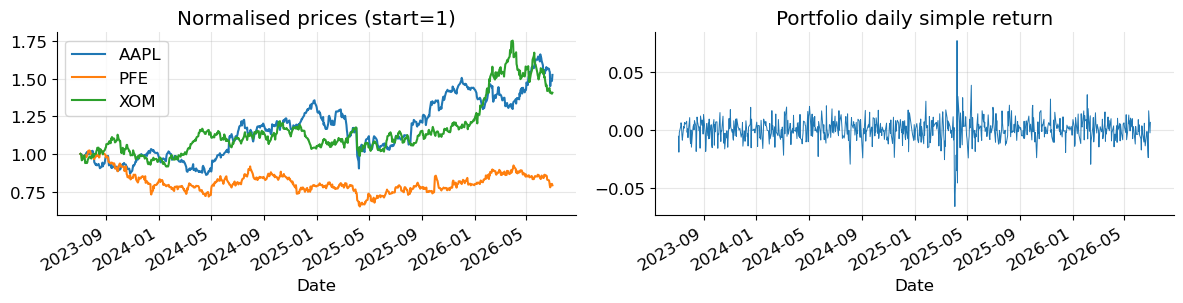

In [2]:
allsyms = TICKERS + [BENCH]
if os.path.exists(CACHE):
    px = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    print(f"Loaded snapshot: {CACHE}")
else:
    px = yf.download(allsyms, start=START, end=END, auto_adjust=True)["Close"]
    px = px[allsyms]
    px.to_csv(CACHE)
    print(f"Downloaded {START} -> {END} from Yahoo Finance, saved to {CACHE}")
px = px[allsyms]

print("Rows:", len(px), "| Missing per column:\n", px.isna().sum().to_string())
px = px.ffill().dropna()

rets = np.log(px / px.shift(1)).dropna()

stocks = TICKERS
r_stk  = rets[stocks]
r_mkt  = rets[BENCH]

simple_stk = px[stocks].pct_change().dropna()
r_port = simple_stk @ WEIGHTS

med   = rets.median()
mad   = (rets - med).abs().median()
z_mad = 0.6745 * (rets - med) / mad
flagged = z_mad.abs() > 5
print("\n|z_MAD|>5 outliers per column (retained as genuine tail risk):\n",
      flagged.sum().to_string())
print("\nNamed outlier days (date | asset | move | robust z):")
for col in allsyms:
    for dt in rets.index[flagged[col]]:
        print(f"  {dt.date()}  {col:<6} {rets.loc[dt, col]*100:+6.2f}%   z_MAD={z_mad.loc[dt, col]:+.1f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
(px[stocks] / px[stocks].iloc[0]).plot(ax=ax[0], title="Normalised prices (start=1)")
r_port.plot(ax=ax[1], title="Portfolio daily simple return", lw=.7)
plt.tight_layout(); plt.show()


**Interpretation:** The snapshot holds 751 trading days, from 2023-07-03 to 2026-06-30, with nothing missing, so the forward fill only guards against halts.

I screen outliers with a median/MAD z-score, not mean/std, because the standard deviation gets inflated by the very shocks I want to find and then hides them. It flags 14 days (AAPL 6, PFE 3, XOM 1, S&P 500 4), not scattered. Eight fall in one week of April 2025. AAPL dropped 9.70% on 3 April and 7.57% on 4 April, then jumped 14.26% on 9 April, while the S&P did -4.96%, -6.16% and +9.09%. The rest are company news, like PFE falling 6.95% on 13 December 2023.

These are real events, not data errors, so I keep all 14, the tail the VaR, ES and GARCH sections measure. Dropping them would flatter every number below.

## 2 · Annualised volatility & correlation

Per-stock risk summary:


,Ann. return,Ann. vol,Sharpe (rf=4%),Max drawdown
XOM,0.115,0.233,0.321,-0.201
PFE,-0.078,0.242,-0.490,-0.364
AAPL,0.142,0.262,0.388,-0.334


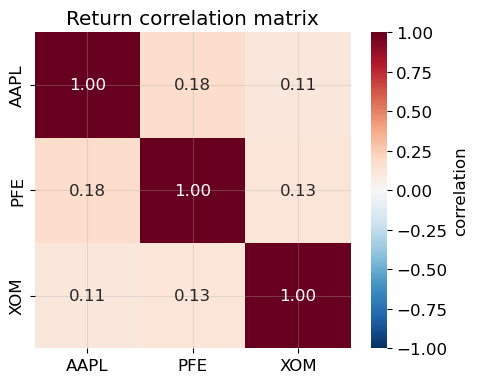

Average pairwise correlation: 0.14
Portfolio vol: 16.1%  |  Diversification ratio: 1.53


In [3]:
summary = pd.DataFrame({
    'Ann. return': r_stk.mean() * 252,
    'Ann. vol':    r_stk.std() * np.sqrt(252),
})
summary['Sharpe (rf=4%)'] = (summary['Ann. return'] - RF_ANNUAL) / summary['Ann. vol']

def max_drawdown(series):
    cum = (1 + series.pct_change().fillna(0)).cumprod()
    return (cum / cum.cummax() - 1).min()
summary['Max drawdown'] = px[stocks].apply(max_drawdown)
print('Per-stock risk summary:')
display(summary.sort_values('Ann. vol').round(3))

corr = r_stk.corr()
avg_corr = corr.values[np.triu_indices(len(stocks), 1)].mean()
fig, ax = plt.subplots(figsize=(5, 4))
if sns is not None:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={'label': 'correlation'}, ax=ax)
else:
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r'); fig.colorbar(im, fraction=.046)
    ax.set_xticks(range(len(stocks))); ax.set_xticklabels(stocks)
    ax.set_yticks(range(len(stocks))); ax.set_yticklabels(stocks)
ax.set_title('Return correlation matrix'); plt.tight_layout(); plt.show()
print(f'Average pairwise correlation: {avg_corr:.2f}')

ann_vol   = r_stk.std() * np.sqrt(252)
port_vol  = r_port.std() * np.sqrt(252)
div_ratio = (WEIGHTS @ ann_vol) / port_vol
print(f'Portfolio vol: {port_vol*100:.1f}%  |  Diversification ratio: {div_ratio:.2f}')


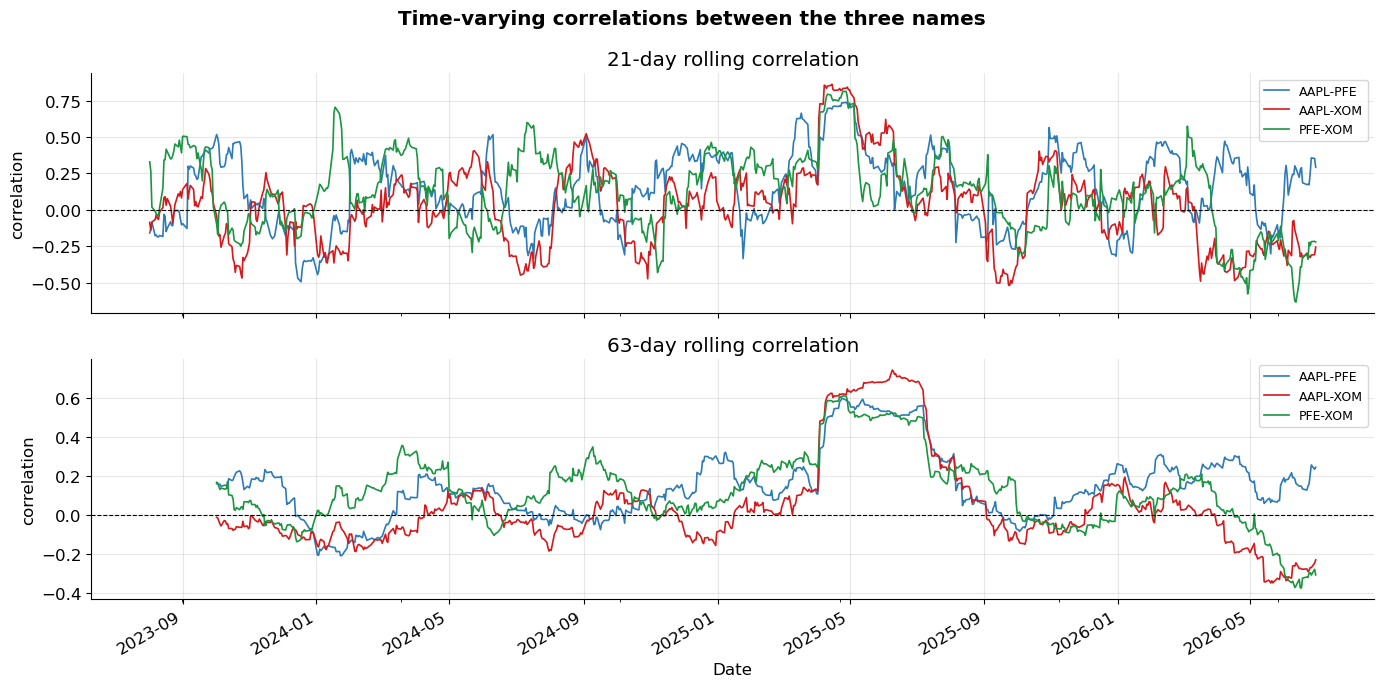

In [4]:
from itertools import combinations
pairs = list(combinations(stocks, 2))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, window, title in zip(axes, [21, 63], ['21-day rolling', '63-day rolling']):
    for (a, b), col in zip(pairs, [BLUE, RED, GREEN]):
        rets[a].rolling(window).corr(rets[b]).plot(ax=ax, color=col, lw=1.2, label=f'{a}-{b}')
    ax.axhline(0, color='black', lw=.8, ls='--')
    ax.set_title(f'{title} correlation'); ax.set_ylabel('correlation'); ax.legend(fontsize=9)
plt.suptitle('Time-varying correlations between the three names', fontweight='bold')
plt.tight_layout(); plt.show()


**Interpretation:** The standalone volatilities sit close, AAPL 26.2%, PFE 24.2% and XOM 23.3% annualised, all normal for large caps. The portfolio lands at just 16.1%, a diversification ratio of 1.53, about a third less volatile than the weighted average of its parts. That comes from the names barely moving together, average pairwise correlation only 0.14, which fits three sectors on different drivers, rates and AI, drug pipelines, and crude.

Low correlation is not good performance, though. PFE returned -0.078 a year for a Sharpe of -0.49, a drag on return while still a diversifier. The rolling chart shows the catch, because those correlations wander and jump together in sell-offs, so 1.53 is a calm-market number that shrinks when I need it most.

## 3 · Beta, systematic vs. idiosyncratic risk, and stylised facts

I run the stylised-fact tests on the portfolio series rather than per name, since the portfolio is what the VaR sections model.

In [5]:
rows = []
for s in stocks:
    slope, intercept, rval, pval, se = stats.linregress(r_mkt, r_stk[s])
    rows.append({'Stock': s,
                 'Ann. vol %':      r_stk[s].std() * np.sqrt(252) * 100,
                 'Beta':            slope,
                 'Beta SE':         se,
                 'Beta p':          pval,
                 'Systematic R2':   rval**2,
                 'Idiosyncratic':   1 - rval**2,
                 'Alpha ann %':     intercept * 252 * 100,
                 'Excess kurtosis': stats.kurtosis(r_stk[s], fisher=True)})
summary_df = pd.DataFrame(rows).set_index('Stock')
print(f'Per-stock beta vs {BENCH} (a broad index would sit near 1, which is the sanity check):')
display(summary_df.round(3))

Per-stock beta vs ^GSPC (a broad index would sit near 1, which is the sanity check):


,Ann. vol %,Beta,Beta SE,Beta p,Systematic R2,Idiosyncratic,Alpha ann %,Excess kurtosis
Stock,,,,,,,,
AAPL,26.203,1.120,0.049,0.0,0.411,0.589,-5.430,10.215
PFE,24.161,0.391,0.057,0.0,0.059,0.941,-14.677,2.082
XOM,23.272,0.242,0.056,0.0,0.024,0.976,7.223,1.588


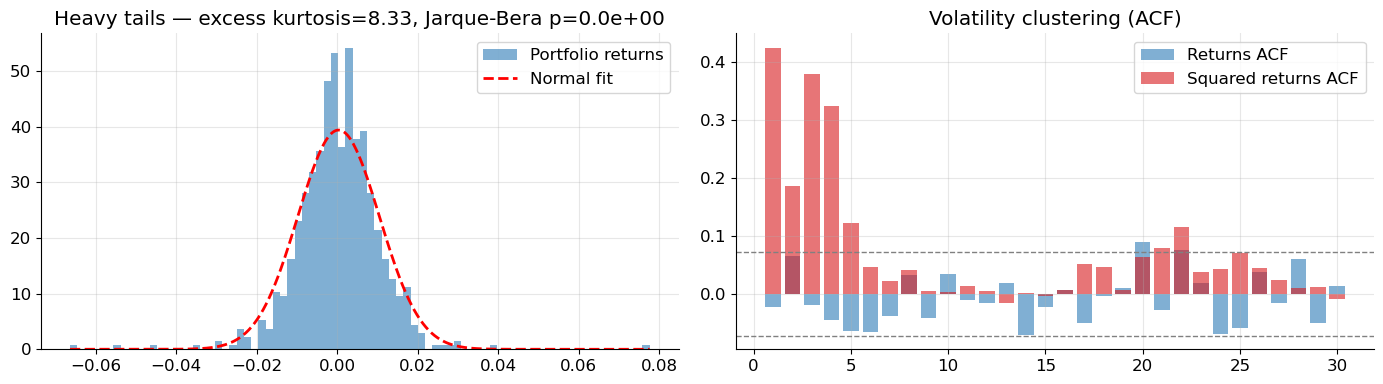

Skew=-0.12   Excess kurtosis=8.33   Jarque-Bera p=0.0e+00


In [6]:
r = r_port
jb_stat, jb_p = stats.jarque_bera(r)

fig = plt.figure(figsize=(14, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.hist(r, bins=80, density=True, alpha=0.6, color=BLUE, label='Portfolio returns')
x = np.linspace(r.min(), r.max(), 400)
ax1.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r--', lw=2, label='Normal fit')
ax1.set_title(f'Heavy tails — excess kurtosis={r.kurtosis():.2f}, Jarque-Bera p={jb_p:.1e}')
ax1.legend()
ax2 = fig.add_subplot(1, 2, 2)
lags = range(1, 31)
ax2.bar(lags, [r.autocorr(l)      for l in lags], alpha=0.6, color=BLUE, label='Returns ACF')
ax2.bar(lags, [(r**2).autocorr(l) for l in lags], alpha=0.6, color=RED,  label='Squared returns ACF')
ci = 1.96 / np.sqrt(len(r))
ax2.axhline(ci, color='gray', ls='--', lw=1); ax2.axhline(-ci, color='gray', ls='--', lw=1)
ax2.set_title('Volatility clustering (ACF)'); ax2.legend()
plt.tight_layout(); plt.show()
print(f'Skew={r.skew():.2f}   Excess kurtosis={r.kurtosis():.2f}   Jarque-Bera p={jb_p:.1e}')


**Interpretation:** The betas split the trio sharply. AAPL at 1.12 is 41% systematic and carries nearly all my market exposure, while PFE at 0.391 and XOM at 0.242 are 94% and 98% idiosyncratic, the diversifiers behind my 16.1% volatility.

XOM's 0.242 is the one I did not trust at first, below the 0.3 to 2 band I expect for a large cap, which usually flags a bad index or data, so I checked it. A standard error of 0.056 and a p-value near zero say the estimate is precise and not zero, and the S&P is the right index for a US book. The low beta is real, because XOM tracks crude and crude did not track the S&P over these three years.

The portfolio also fails the Normal, with excess kurtosis 8.33, AAPL alone at 10.215, and a Jarque-Bera p of zero to machine precision. The ACF plot separates the two effects, with nothing past lag 1 in raw returns but squared returns significant for many lags, so returns are unpredictable in direction yet predictable in size, which breaks a constant-Normal VaR.

## 4 · 1-day 99% VaR by three methods

The one design choice worth flagging is the Monte Carlo. A Normal draw would just re-run parametric's assumption, so instead I draw 200,000 scenarios from a multivariate Student-t (ν = 5) scaled to the sample covariance, changing only the tail shape. A Normal MC runs alongside as a check.

                      1-day 99% VaR
Parametric (Normal)          2.32 %
Historical                   2.42 %
Monte Carlo (t, nu=5)        2.62 %

Max-min spread as % of mean VaR: 12%
(A Normal MC gives 2.32%, essentially the parametric 2.32% -> it only repeats the parametric method, so the fat-tailed t is what makes MC a real third estimate.)


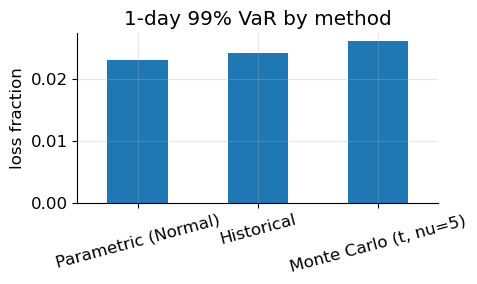

In [7]:
mu_p, sig_p = r_port.mean(), r_port.std()

var_param = -(mu_p + Z*sig_p)

var_hist = -np.percentile(r_port, 100*ALPHA)

rng   = np.random.default_rng(42)
nu_mc = 5
mean  = simple_stk.mean().values
cov   = simple_stk.cov().values
Sig   = cov * (nu_mc - 2) / nu_mc
L     = np.linalg.cholesky(Sig)
N     = 200_000
znorm = rng.standard_normal((N, len(stocks))) @ L.T
gchi  = rng.chisquare(nu_mc, N) / nu_mc
sims  = (mean + znorm / np.sqrt(gchi)[:, None]) @ WEIGHTS
var_mc = -np.percentile(sims, 100*ALPHA)

vardf = pd.DataFrame({"1-day 99% VaR": [var_param, var_hist, var_mc]},
                     index=["Parametric (Normal)", "Historical", f"Monte Carlo (t, nu={nu_mc})"])
print((vardf*100).round(2).astype(str).add(" %").to_string())
spread = (vardf.max().iloc[0]-vardf.min().iloc[0]) / vardf.mean().iloc[0]
print(f"\nMax-min spread as % of mean VaR: {spread*100:.0f}%")

sims_norm  = rng.multivariate_normal(mean, cov, size=N) @ WEIGHTS
var_mc_norm = -np.percentile(sims_norm, 100*ALPHA)
print(f"(A Normal MC gives {var_mc_norm*100:.2f}%, essentially the parametric "
      f"{var_param*100:.2f}% -> it only repeats the parametric method, so the "
      f"fat-tailed t is what makes MC a real third estimate.)")

vardf.plot.bar(legend=False, figsize=(5,3), title="1-day 99% VaR by method", rot=15)
plt.ylabel("loss fraction"); plt.tight_layout(); plt.show()


**Interpretation:** The three methods disagree sensibly. Parametric gives 2.32%, historical 2.42% and the Student-t Monte Carlo 2.62%, a spread of about 12% of the mean VaR, all low single digits.

The ordering is the informative part. The t-MC is highest because its fat tails weight the extreme-loss region more than a Normal allows, historical sits in the middle because it feels the actual April 2025 days, and parametric is lowest because the Normal tail is thinnest, which lines up with the kurtosis of 8.33. The Normal MC confirms it, matching parametric at 2.32%, so it would have been a copy.

So my VaR is really a range from 2.32% to 2.62%, and which end I quote is a modelling choice, not a measurement. My window is calm, though, so at a more extreme quantile or with a real crash the fat-tailed estimate would pull much further away and 12% would look small.

## 5 · Expected Shortfall & sub-additivity

For the super-additivity test I compare each name's VaR at its portfolio weight against the portfolio VaR, since full positions against a one-third weighting would rig it. I run five confidence levels, since one can pass by luck.

In [8]:
tail = r_port[r_port <= -var_hist]
es_hist  = -tail.mean()
es_param = -(mu_p - sig_p*stats.norm.pdf(Z)/ALPHA)
print(f"Historical  VaR {var_hist*100:.2f}%   ES {es_hist*100:.2f}%   ES/VaR {es_hist/var_hist:.2f}")
print(f"Parametric  VaR {var_param*100:.2f}%   ES {es_param*100:.2f}%   ES/VaR {es_param/var_param:.2f}")

print("\nSuper-additivity across confidence levels (historical, weight-consistent):")
print(f"  {'conf':>6} {'sum comp':>9} {'portfolio':>10} {'benefit':>9}   verdict")
for conf in [0.90, 0.95, 0.99, 0.995, 0.999]:
    a    = 1 - conf
    comp = sum(-np.percentile(WEIGHTS[i]*simple_stk[s], 100*a) for i, s in enumerate(stocks))
    port = -np.percentile(r_port, 100*a)
    verdict = "sub-additive" if port <= comp else "SUPER-ADDITIVE (VaR fails!)"
    print(f"  {conf*100:5.1f}% {comp*100:8.2f}% {port*100:9.2f}% {(comp-port)*100:7.2f}pp   {verdict}")


Historical  VaR 2.42%   ES 3.89%   ES/VaR 1.60
Parametric  VaR 2.32%   ES 2.66%   ES/VaR 1.15

Super-additivity across confidence levels (historical, weight-consistent):
    conf  sum comp  portfolio   benefit   verdict
   90.0%     1.73%      1.06%    0.66pp   sub-additive
   95.0%     2.42%      1.45%    0.97pp   sub-additive
   99.0%     4.08%      2.42%    1.66pp   sub-additive
   99.5%     4.70%      3.11%    1.59pp   sub-additive
   99.9%     6.50%      5.70%    0.80pp   sub-additive


**Interpretation:** Historical ES is 3.89% against a VaR of 2.42%, so on the worst 1% of days my average loss is 1.6 times the VaR threshold.

Parametric ES is 2.66%, a ratio of 1.15 against the historical 1.60, yet the two VaRs are nearly identical at 2.32% and 2.42%. So the Normal assumption looks almost harmless at the threshold and badly wrong just past it, which is the real argument for ES.

On sub-additivity, my portfolio VaR sits below the summed component VaRs at every level from 90% to 99.9%, and the benefit grows from 0.66pp to a peak of 1.66pp at 99%, so diversification is rewarded and never turns super-additive here. But this is a fact about my sample, not a property of VaR, following from the 0.14 correlation, and with skewed or fat-tailed positions VaR can punish diversification where ES is coherent and cannot. I would not lean on the 99.9% row, where the benefit falls to 0.80pp on a tail of roughly 7 days out of 750, sampling noise.

## 6 · Time-varying volatility with GARCH(1,1)

Two choices to flag. I pick the stock with a Ljung-Box test for clustering across all three, taking the strongest rejection not the most volatile name, and I fit Student-t innovations checked with AIC. The VaR and ES use the fitted t quantile.

Volatility-clustering test (Ljung-Box on squared returns, lag 10):
  AAPL   LB(squared) p = 8.75e-27
  PFE    LB(squared) p = 0.00128
  XOM    LB(squared) p = 1.01e-15
-> GARCH target chosen by clustering evidence: AAPL
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.4927      0.703      0.701      0.483    [ -0.885,  1.870]
alpha[1]       0.1240      0.112      1.105      0.269 [-9.600e-02,  0.344]
beta[1]        0.7096      0.352      2.019  4.353e-02  [2.059e-02,  1.399]

Parameter significance: omega p=0.483 (NOT significant), alpha p=0.269 (NOT significant), beta p=0.0435 (significant), nu p=1.43e-13
Persistence (alpha+beta) = 0.834 < 1  |  long-run vol 27.3%/yr  |  shock half-life 3.8 days  |  Student-t dof nu = 3.58


AIC: Student-t 2675.2 vs Normal 2784.5  -> t preferred (fat tails earn their keep)
Standardised-t 1% quantile = -2.659  (Normal z = -2.326)   |   ES multiplier = 3.830  (Normal = 2.665)

1-day GARCH cond. vol forecast: 2.25%   (constant 1.65%)
GARCH-t    AAPL: VaR 5.99%   ES 8.63%
Constant-t AAPL: VaR 4.39%   ES 6.32%


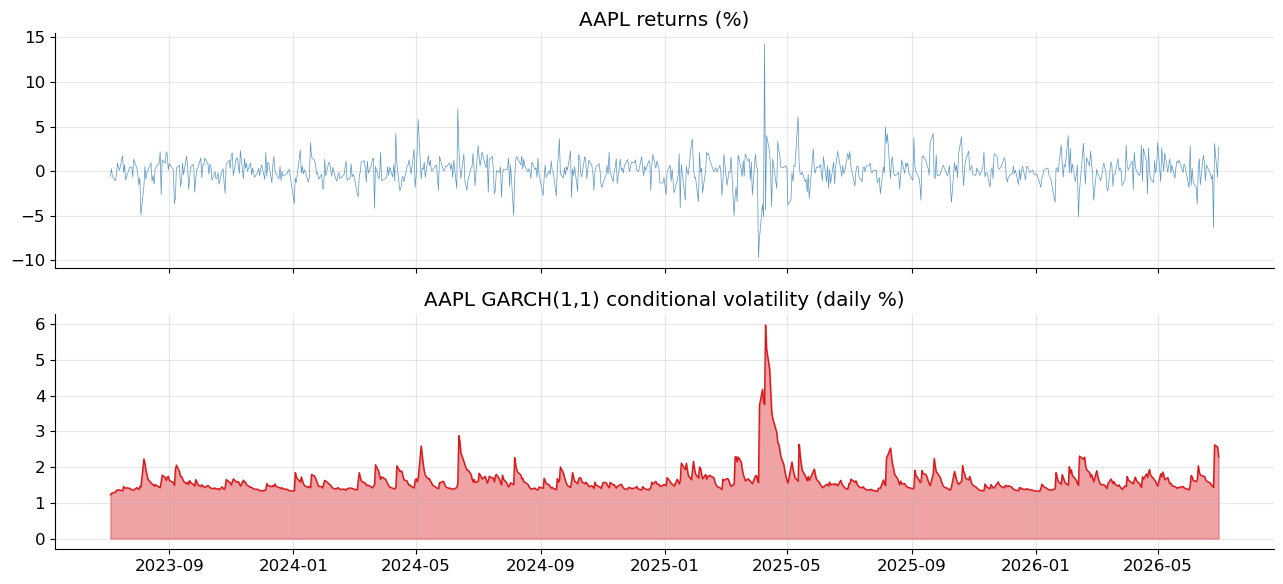

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox
print("Volatility-clustering test (Ljung-Box on squared returns, lag 10):")
lb = {}
for s in stocks:
    lb[s] = acorr_ljungbox(r_stk[s]**2, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    print(f"  {s:<6} LB(squared) p = {lb[s]:.3g}")
target = min(lb, key=lb.get)
print(f"-> GARCH target chosen by clustering evidence: {target}")

r_pct  = r_stk[target] * 100
res    = arch_model(r_pct, vol='Garch', p=1, q=1, dist='t', mean='Zero').fit(disp='off')
print(res.summary().tables[1])

w, a, b = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
nu      = res.params['nu']
pv      = res.pvalues
persist = a + b
sig = lambda p: 'significant' if p < 0.05 else 'NOT significant'
print(f"\nParameter significance: omega p={pv['omega']:.3g} ({sig(pv['omega'])}), "
      f"alpha p={pv['alpha[1]']:.3g} ({sig(pv['alpha[1]'])}), "
      f"beta p={pv['beta[1]']:.3g} ({sig(pv['beta[1]'])}), nu p={pv['nu']:.3g}")

if persist < 1:
    uncond_vol = np.sqrt(w/(1-persist)) / 100 * np.sqrt(252)
    half_life  = np.log(0.5)/np.log(persist)
    print(f"Persistence (alpha+beta) = {persist:.3f} < 1  |  long-run vol "
          f"{uncond_vol*100:.1f}%/yr  |  shock half-life {half_life:.1f} days  |  "
          f"Student-t dof nu = {nu:.2f}")
else:
    uncond_vol = half_life = np.nan
    print(f"Persistence (alpha+beta) = {persist:.3f} >= 1: near-integrated (IGARCH) "
          f"fit -> long-run variance UNDEFINED (boundary fit). Do NOT report an "
          f"unconditional vol or half-life here; treat the persistence itself as "
          f"the finding and investigate.")

res_norm = arch_model(r_pct, vol='Garch', p=1, q=1, dist='normal', mean='Zero').fit(disp='off')
print(f"AIC: Student-t {res.aic:.1f} vs Normal {res_norm.aic:.1f}  -> "
      f"{'t preferred (fat tails earn their keep)' if res.aic < res_norm.aic else 'Normal preferred'}")

cond_vol = res.conditional_volatility
sig_fc   = np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0]) / 100
sig_bar  = r_stk[target].std()

q_raw = stats.t.ppf(ALPHA, nu)
scale = np.sqrt((nu - 2) / nu)
q_t   = q_raw * scale
es_t  = (stats.t.pdf(q_raw, nu)/ALPHA) * (nu + q_raw**2)/(nu - 1) * scale
print(f"Standardised-t 1% quantile = {q_t:.3f}  (Normal z = {Z:.3f})   |   "
      f"ES multiplier = {es_t:.3f}  (Normal = {stats.norm.pdf(Z)/ALPHA:.3f})")

var_garch = -sig_fc  * q_t
es_garch  =  sig_fc  * es_t
var_const = -sig_bar * q_t
es_const  =  sig_bar * es_t
print(f"\n1-day GARCH cond. vol forecast: {sig_fc*100:.2f}%   (constant {sig_bar*100:.2f}%)")
print(f"GARCH-t    {target}: VaR {var_garch*100:.2f}%   ES {es_garch*100:.2f}%")
print(f"Constant-t {target}: VaR {var_const*100:.2f}%   ES {es_const*100:.2f}%")

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(r_pct.index, r_pct, color=BLUE, lw=.5, alpha=.8)
ax[0].set_title(f'{target} returns (%)')
ax[1].fill_between(cond_vol.index, cond_vol, alpha=.4, color=RED)
ax[1].plot(cond_vol.index, cond_vol, color=RED, lw=1)
ax[1].set_title(f'{target} GARCH(1,1) conditional volatility (daily %)')
plt.tight_layout(); plt.show()


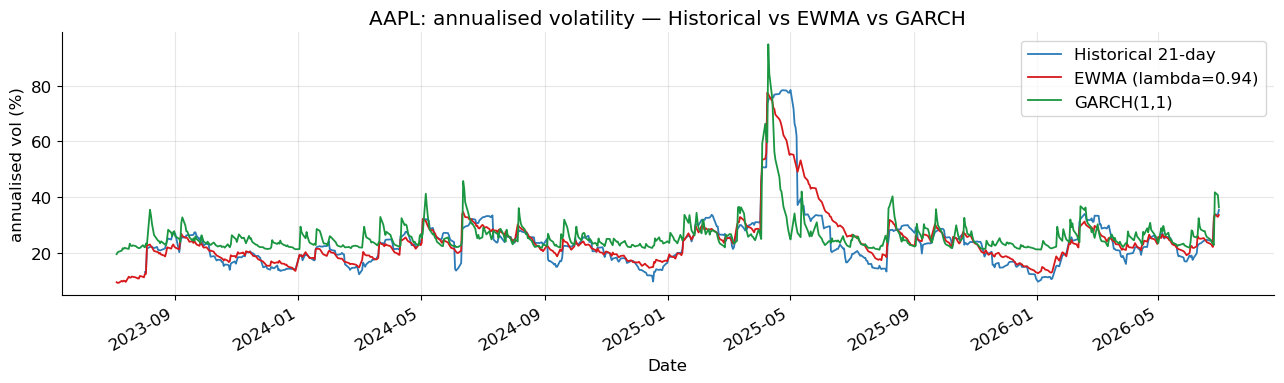

In [10]:
lam = 0.94
r_t = r_stk[target]
hist_vol = r_t.rolling(21).std() * np.sqrt(252) * 100
ewma_var = r_t.copy(); ewma_var.iloc[0] = r_t.iloc[0]**2
for t in range(1, len(r_t)):
    ewma_var.iloc[t] = lam * ewma_var.iloc[t-1] + (1-lam) * r_t.iloc[t]**2
ewma_vol  = np.sqrt(ewma_var) * np.sqrt(252) * 100
garch_vol = cond_vol * np.sqrt(252)

fig, ax = plt.subplots(figsize=(13, 4))
hist_vol.plot(ax=ax,  color=BLUE,  lw=1.3, label='Historical 21-day')
ewma_vol.plot(ax=ax,  color=RED,   lw=1.3, label=f'EWMA (lambda={lam})')
garch_vol.plot(ax=ax, color=GREEN, lw=1.3, label='GARCH(1,1)')
ax.set_title(f'{target}: annualised volatility — Historical vs EWMA vs GARCH')
ax.set_ylabel('annualised vol (%)'); ax.legend(); plt.tight_layout(); plt.show()


**Interpretation:** The Ljung-Box test picks the stock. AAPL rejects no-clustering hardest at p = 8.75e-27, against 1.01e-15 for XOM and only 0.00128 for PFE, so PFE is barely clustered at almost the same volatility, and clustering is not volatility.

Persistence is 0.834, from alpha 0.124 and beta 0.7096, below 1, so the long-run variance is defined. It comes out at 27.3% a year, right next to AAPL's 26.2% sample volatility. The half-life is 3.8 days, lower than the 0.95 to 0.99 usual in long daily samples, probably because my window is short and April 2025 spiked and reversed fast.

In the coefficient table, beta at p = 0.0435 and nu at p = 1.43e-13 are significant, but omega at p = 0.483 and alpha at p = 0.269 are not, with intervals crossing zero, so I lean on the joint persistence the VaR depends on. AIC backs the t at 2675.2 against 2784.5, and nu = 3.58 is very heavy.

The forecast is 2.25% daily against a 1.65% constant, both on the same t quantile so the gap isolates the regime. VaR is 5.99% against 4.39%, ES 8.63% against 6.32%, and a desk on the constant number is under-capitalised on AAPL by about a third today.

## 7 · Backtest & Basel traffic light

I roll a 500-day estimation window and count exceptions over a 250-day test block, the horizon Basel's zones use (Green 0 to 4, Yellow 5 to 9, Red 10 or more). The by-year check uses a 250-day window instead, since 500 days on my 750-day sample just reproduces the headline 250 days, so the two counts are not strictly comparable.

Basel zone read on 250 obs -> Exceptions: 1 / 250   Expected: 2.5   Zone: GREEN

Breaches by year, 250-day estimation window (500 days covered vs 250 on a 500-day window):
      exceptions  days  rate %
2024           3   127    2.36
2025           5   250    2.00
2026           2   123    1.63
Worst single year: 5 breaches in 2025 (250 days covered).

Kupiec POF          LR = 1.18  p = 0.28   (>3.84 rejects correct 99% coverage)
Christoffersen ind. LR = 0.01  p = 0.93   (>3.84 => exceptions cluster)
Conditional coverage LR_cc = 1.18  (df=2; >5.99 => reject jointly)


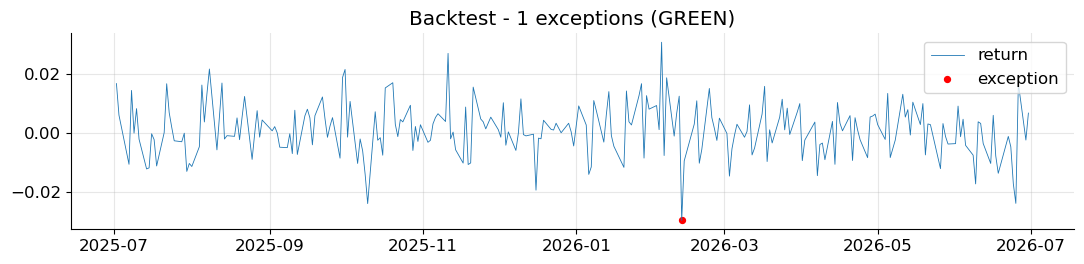

In [11]:
from scipy.stats import chi2
win, test_n = 500, 250
series = r_port.values
exc = []
for t in range(len(series)-test_n, len(series)):
    hist = series[t-win:t]
    v = -(hist.mean() + Z*hist.std())
    exc.append(series[t] < -v)
exc = np.array(exc)
n_exc, expected = exc.sum(), ALPHA*test_n
zone = "GREEN" if n_exc <= 4 else "YELLOW" if n_exc <= 9 else "RED"
print(f"Basel zone read on 250 obs -> Exceptions: {n_exc} / {test_n}   "
      f"Expected: {expected:.1f}   Zone: {zone}")

diag_win = 250
fi, fe = [], []
for t in range(diag_win, len(series)):
    hist = series[t-diag_win:t]
    v = -(hist.mean() + Z*hist.std())
    fi.append(r_port.index[t]); fe.append(series[t] < -v)
full = pd.Series(fe, index=pd.DatetimeIndex(fi))
by_year = full.groupby(full.index.year).agg(exceptions='sum', days='count')
by_year['rate %'] = (by_year['exceptions']/by_year['days']*100).round(2)
print(f"\nBreaches by year, {diag_win}-day estimation window ({len(full)} days "
      f"covered vs {len(series)-win} on a {win}-day window):")
print(by_year.to_string())
worst = int(by_year['exceptions'].max())
worst_yr = int(by_year['exceptions'].idxmax())
worst_days = int(by_year.loc[worst_yr, 'days'])
print(f"Worst single year: {worst} breaches in {worst_yr} ({worst_days} days covered).")

def kupiec_pof(x, n, alpha):
    p, p_hat = alpha, x/n
    if p_hat in (0, 1): return np.nan, np.nan
    lr = -2*(x*np.log(p/p_hat) + (n-x)*np.log((1-p)/(1-p_hat)))
    return lr, chi2.sf(lr, df=1)

def christoffersen_ind(v):
    v = v.astype(int)
    n00=int(((v[:-1]==0)&(v[1:]==0)).sum()); n01=int(((v[:-1]==0)&(v[1:]==1)).sum())
    n10=int(((v[:-1]==1)&(v[1:]==0)).sum()); n11=int(((v[:-1]==1)&(v[1:]==1)).sum())
    pi01 = n01/(n00+n01) if (n00+n01) else 0.0
    pi11 = n11/(n10+n11) if (n10+n11) else 0.0
    pi   = (n01+n11)/(n00+n01+n10+n11)
    if pi in (0,1) or pi01 in (0,1): return np.nan, np.nan, (pi01, pi11)
    sl = lambda x: np.log(max(x, 1e-300))
    ll0 = (n00+n10)*sl(1-pi) + (n01+n11)*sl(pi)
    ll1 = n00*sl(1-pi01)+n01*sl(pi01)+n10*sl(1-pi11)+n11*sl(pi11)
    lr = -2*(ll0-ll1)
    return lr, chi2.sf(lr, df=1), (pi01, pi11)

LR, p_uc = kupiec_pof(int(n_exc), test_n, ALPHA)
LR_ind, p_ind, _ = christoffersen_ind(exc)
print(f"\nKupiec POF          LR = {LR:.2f}  p = {p_uc:.2f}   (>3.84 rejects correct 99% coverage)")
if not np.isnan(LR_ind):
    LR_cc = LR + LR_ind
    print(f"Christoffersen ind. LR = {LR_ind:.2f}  p = {p_ind:.2f}   (>3.84 => exceptions cluster)")
    print(f"Conditional coverage LR_cc = {LR_cc:.2f}  (df=2; >5.99 => reject jointly)")
else:
    print("Christoffersen ind.: too few exceptions -> clustering not detectable "
          "(low power: ~2.5 breaches expected per 250 days at 99%).")

test_ret = r_port.iloc[-test_n:]
plt.figure(figsize=(11,2.8))
plt.plot(test_ret.index, test_ret.values, lw=.6, label="return")
plt.scatter(test_ret.index[exc], test_ret.values[exc], c="red", s=18, label="exception")
plt.title(f"Backtest - {n_exc} exceptions ({zone})"); plt.legend(); plt.tight_layout(); plt.show()

**Interpretation:** The headline is clean and boring. One exception in 250 days against 2.5 expected is Basel GREEN. Kupiec gives LR = 1.18 with p = 0.28, so I cannot reject correct coverage, and Christoffersen's LR = 0.01 with p = 0.93 says the breach is isolated, not the start of a cluster.

The by-year table stops me believing it, the most interesting output here. Rolling the same VaR back gives 3 breaches in 2024, 5 in 2025 and 2 in 2026, and five on a 250-day year is Yellow. So my calm recent window is hiding a worse year, the April 2025 tariff week doing most of the work, and the GREEN really describes the last twelve months.

I should be careful, though. The by-year model uses the shorter window and every year runs above the 1% target, at 2.36%, 2.00% and 1.63%, so some of that is the noisier window misfiring. 2025 is not proof the 500-day model would have gone Yellow, but it shows my GREEN is fragile, changing zone the moment I change one modelling choice. Power is the deeper limit, since at 99% only about 2.5 breaches are expected a year, so one quiet block is weak evidence and my sample holds nothing like 2008 or March 2020. I read this GREEN as weak evidence, not validation.

## 8 · Assumptions, limitations & real-world implications

Every method leans on an assumption my data breaks. Parametric VaR and ES want Normal, independent returns I do not have, historical simulation assumes three years represent the future, my Monte Carlo only trades that for my own choice of nu = 5, and beta assumes a stable link my drifting correlations would break in a crisis. Running all three makes that model risk visible instead of hiding it in one number.

The rest is about my sample, which covers one calm regime, so my clean backtest and diversification benefit are both measured where risk is easiest. A three-name book also leaves so much idiosyncratic risk that a market-risk framework only sees part of the danger. AAPL sets the buffer, while PFE and XOM need position limits for risk hedges cannot touch, a failed trial or a crude move. Risk management is not one number, and the discipline is knowing what each tool cannot see.